<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/digital_twin_model_vs_measurement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital twin: NeqSim model versus plant measurements

**Audience.** Process, rotating-equipment, reliability, and digital-twin engineers who
want a reproducible model–measurement workflow rather than an isolated simulation.

**Prerequisites.** Basic Python, natural-gas compression, residuals, and SI engineering
units. No local NeqSim installation, plant connection, or proprietary data is required.


## Learning objectives

After completing the notebook, you can:

1. create and flash the original six-component SRK gas in NeqSim;
2. assemble `Stream`, `Compressor`, and `ProcessSystem` objects;
3. preserve and reproduce the original four operating points and comparison figure;
4. distinguish process-model power from synthetic package-level measurements;
5. calculate residual, RMSE, bias, and validation error;
6. fit a transparent calibration on training data without hiding the raw model;
7. use NeqSim's `BatchParameterEstimator` to recover compressor efficiency;
8. run a 24-hour model-in-the-loop monitoring application; and
9. detect sustained residual drift with explicit engineering checks.


## Preservation checklist

The previous notebook contained four substantive examples and one substantive figure.
Every item is retained and integrated:

- the original nitrogen/CO2/C1–C4 SRK fluid;
- the exact four-row synthetic measurement table;
- one fresh NeqSim compressor process per measurement row; and
- the original measured-versus-simulated power chart.

The power chart remains recognizable, while its simulated values are refreshed with an
explicit 0.78 isentropic efficiency and current NeqSim 3.16.0 APIs. Six new technical
figures are additions, not substitutes.


## 1. Clean Colab setup

The setup installs the latest public PyPI package only when NeqSim is absent. It records
the actual package and runtime versions for traceability.


In [1]:
import importlib.metadata
import platform
import subprocess
import sys

try:
    import neqsim
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )
    import neqsim

neqsim_version = importlib.metadata.version("neqsim")
java_version = platform.java_ver()[0]

if not java_version:
    java_version = subprocess.check_output(
        ["java", "-version"],
        stderr=subprocess.STDOUT,
        text=True,
    ).splitlines()[0]

print(f"NeqSim package: {neqsim_version}")
print(f"Python runtime: {platform.python_version()}")
print(f"Java runtime: {java_version}")


NeqSim package: 3.16.0
Python runtime: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


In [2]:
import contextlib
import io
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from jpype import JClass, JDouble
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from neqsim import jneqsim

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "grey": "#666666",
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


## 2. Digital-twin concept

A digital twin combines a physics model, measured boundary conditions, observations,
calibration logic, and health rules. For operating point $i$, the raw model prediction is:

$$
\hat{y}_i = f_{NeqSim}(x_i, \theta)
$$

Here $x_i$ contains flow, suction pressure, and discharge pressure; $\theta$ contains
model parameters such as efficiency; and $\hat{y}_i$ is predicted compressor power in kW.


The measurement residual and root-mean-square error are:

$$
e_i = y_i - \hat{y}_i
$$

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n} e_i^2}
$$

A residual is evidence of mismatch, not automatically equipment degradation. Sensor bias,
package boundaries, auxiliaries, composition, efficiency, heat loss, and timing alignment
must be investigated before drawing a diagnosis.


## 3. Assumptions and validity limits

- Each row is steady state and time-aligned.
- The preserved measurements are explicitly synthetic, not an authoritative benchmark.
- NeqSim models a single adiabatic compressor with fixed isentropic efficiency.
- The synthetic measured power is treated as package-level power and may include systematic
  scale and auxiliary-load effects outside the compressor thermodynamic boundary.
- SRK with the classic mixing rule is a screening choice for this hydrocarbon gas.
- No compressor map, anti-surge control, mechanical loss model, uncertainty propagation,
  historian connection, or cybersecurity layer is included.
- Calibration must be trained on one data subset and validated on unseen points.


## 4. Current NeqSim objects used

- `SystemSrkEos` represents the multicomponent fluid and phase equilibrium.
- `ThermodynamicOperations.TPflash()` establishes each inlet state.
- `Stream` carries fluid, flow, pressure, and temperature.
- `Compressor` applies outlet pressure and isentropic efficiency.
- `ProcessSystem` executes the connected equipment in order.
- `BatchParameterEstimator` performs bounded Levenberg–Marquardt parameter estimation.

The final monitoring workflow builds fresh objects for every timestamp, preventing hidden
state from contaminating comparisons.


## 5. Original gas example: preserved

The original mole fractions are unchanged and sum to one. The explicit flash and property
initialization make the starting state reproducible.


In [3]:
original_composition = {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.86,
    "ethane": 0.07,
    "propane": 0.03,
    "n-butane": 0.01,
}

model_basis = {
    "temperature_c": 25.0,
    "isentropic_efficiency": 0.78,
}

assert math.isclose(
    sum(original_composition.values()),
    1.0,
    rel_tol=0.0,
    abs_tol=1.0e-12,
)

display(
    pd.DataFrame(
        {
            "Component": list(original_composition),
            "Mole fraction [-]": list(original_composition.values()),
        }
    )
)


,Component,Mole fraction [-]
0,nitrogen,0.01
1,CO2,0.02
2,methane,0.86
3,ethane,0.07
4,propane,0.03
5,n-butane,0.01


In [4]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def make_gas(
    temperature_c=25.0,
    pressure_bara=60.0,
    flow_kg_h=9000.0,
):
    fluid = SystemSrkEos(temperature_c + 273.15, pressure_bara)

    for component_name, mole_fraction in original_composition.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow_kg_h, "kg/hr")
    operations = ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.init(0)
    fluid.init(1)
    fluid.initPhysicalProperties()
    return fluid


In [5]:
reference_fluid = make_gas()
reference_properties = pd.DataFrame(
    [
        {
            "Temperature [°C]": reference_fluid.getTemperature("C"),
            "Pressure [bara]": reference_fluid.getPressure("bara"),
            "Mass flow [kg/h]": reference_fluid.getFlowRate("kg/hr"),
            "Molar mass [kg/mol]": (
                reference_fluid.getMolarMass("kg/mol")
            ),
            "Density [kg/m³]": reference_fluid.getDensity("kg/m3"),
            "Enthalpy [kJ/kg]": (
                reference_fluid.getEnthalpy("J/kg") / 1000.0
            ),
        }
    ]
)
display(reference_properties.round(6))


,Temperature [°C],Pressure [bara],Mass flow [kg/h],Molar mass [kg/mol],Density [kg/m³],Enthalpy [kJ/kg]
0,25.0,60.0,9000.0,0.018966,53.117251,2.096521


The flashed property table is a reproducibility checkpoint. Properties are never copied as
constants into the downstream calculation; each operating point is flashed again at its
measured suction pressure.


## 6. Twin workflow overview

The diagram separates raw measurements, the physics model, calibration, validation, and
online residual monitoring.


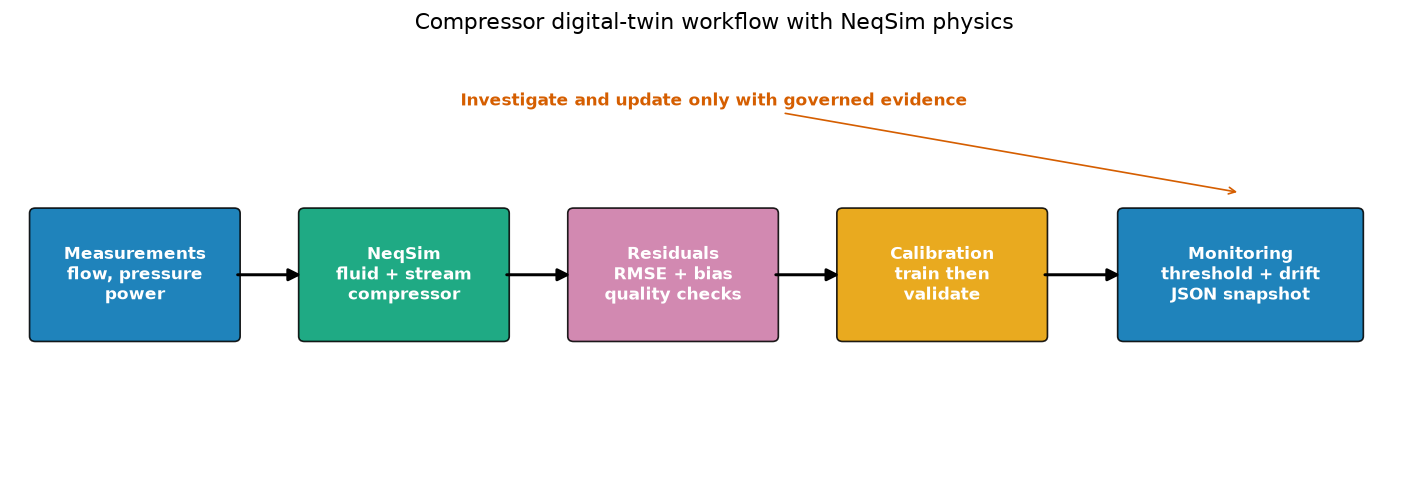

In [6]:
figure, axis = plt.subplots(figsize=(12.0, 4.2))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.2)
axis.axis("off")

boxes = [
    (0.2, 1.4, 1.7, 1.2, "Measurements\nflow, pressure\npower", "blue"),
    (2.5, 1.4, 1.7, 1.2, "NeqSim\nfluid + stream\ncompressor", "green"),
    (4.8, 1.4, 1.7, 1.2, "Residuals\nRMSE + bias\nquality checks", "purple"),
    (7.1, 1.4, 1.7, 1.2, "Calibration\ntrain then\nvalidate", "orange"),
    (9.5, 1.4, 2.0, 1.2, "Monitoring\nthreshold + drift\nJSON snapshot", "blue"),
]

for x_value, y_value, width, height, label, colour_key in boxes:
    patch = FancyBboxPatch(
        (x_value, y_value),
        width,
        height,
        boxstyle="round,pad=0.05",
        facecolor=COLORS[colour_key],
        edgecolor="black",
        alpha=0.88,
    )
    axis.add_patch(patch)
    axis.text(
        x_value + width / 2.0,
        y_value + height / 2.0,
        label,
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

for start_x, end_x in [(1.9, 2.5), (4.2, 4.8), (6.5, 7.1), (8.8, 9.5)]:
    axis.add_patch(
        FancyArrowPatch(
            (start_x, 2.0),
            (end_x, 2.0),
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.8,
            color="black",
        )
    )

axis.annotate(
    "Investigate and update only with governed evidence",
    xy=(10.5, 2.8),
    xytext=(6.0, 3.65),
    arrowprops={"arrowstyle": "->", "color": COLORS["red"]},
    color=COLORS["red"],
    ha="center",
    fontweight="bold",
)
axis.set_title(
    "Compressor digital-twin workflow with NeqSim physics",
    fontsize=13,
    pad=12,
)
plt.tight_layout()
plt.show()


The process model is one element of the twin. Calibration does not erase the raw model:
both predictions remain available so package-boundary corrections cannot be mistaken for
thermodynamic parameters.


## 7. Original synthetic measurements: preserved exactly

These four rows are unchanged. Their values are synthetic and are used to teach workflow
mechanics, not to validate a compressor vendor model.


In [7]:
measurements = pd.DataFrame(
    {
        "flow_kg_per_hr": [7000, 8500, 10000, 11500],
        "suction_pressure_bara": [48, 50, 52, 53],
        "discharge_pressure_bara": [95, 98, 102, 106],
        "measured_power_kW": [880, 990, 1135, 1280],
    }
)
display(measurements)


,flow_kg_per_hr,suction_pressure_bara,discharge_pressure_bara,measured_power_kW
0,7000,48,95,880
1,8500,50,98,990
2,10000,52,102,1135
3,11500,53,106,1280


In [8]:
measurement_quality = pd.DataFrame(
    [
        {
            "Check": "No missing values",
            "Passed": not measurements.isna().any().any(),
        },
        {
            "Check": "Positive mass flow",
            "Passed": measurements["flow_kg_per_hr"].gt(0.0).all(),
        },
        {
            "Check": "Discharge exceeds suction pressure",
            "Passed": (
                measurements["discharge_pressure_bara"]
                > measurements["suction_pressure_bara"]
            ).all(),
        },
        {
            "Check": "Monotonic timestamp surrogate",
            "Passed": measurements.index.is_monotonic_increasing,
        },
        {
            "Check": "Power is positive",
            "Passed": measurements["measured_power_kW"].gt(0.0).all(),
        },
    ]
)
display(measurement_quality)
assert measurement_quality["Passed"].all()


,Check,Passed
0,No missing values,True
1,Positive mass flow,True
2,Discharge exceeds suction pressure,True
3,Monotonic timestamp surrogate,True
4,Power is positive,True


A real implementation also checks timestamps, unit metadata, tag status, sensor range,
steady-state windows, missing intervals, duplicate samples, and maintenance flags.


## 8. Reusable NeqSim compressor evaluator

Each call creates a fresh fluid and process. This avoids the hidden-state problem that can
occur when one mutable flowsheet is repeatedly changed across historian rows.


In [9]:
def simulate_compressor_case(
    flow_kg_h,
    suction_pressure_bara,
    discharge_pressure_bara,
    isentropic_efficiency=0.78,
    temperature_c=25.0,
):
    fluid = make_gas(
        temperature_c=temperature_c,
        pressure_bara=suction_pressure_bara,
        flow_kg_h=flow_kg_h,
    )
    case_name = (
        f"F{flow_kg_h:.0f}_"
        f"Pin{suction_pressure_bara:.1f}_"
        f"Pout{discharge_pressure_bara:.1f}"
    )
    feed = Stream(f"{case_name} feed", fluid)
    compressor = Compressor(f"{case_name} compressor", feed)
    compressor.setOutletPressure(discharge_pressure_bara, "bara")
    compressor.setIsentropicEfficiency(isentropic_efficiency)
    process = ProcessSystem()
    process.add(feed)
    process.add(compressor)
    process.run()
    discharge = compressor.getOutletStream()
    mass_flow_kg_s = feed.getFlowRate("kg/sec")
    enthalpy_rate_change_w = mass_flow_kg_s * (
        discharge.getFluid().getEnthalpy("J/kg")
        - feed.getFluid().getEnthalpy("J/kg")
    )
    result = {
        "flow_kg_per_hr": flow_kg_h,
        "suction_pressure_bara": suction_pressure_bara,
        "discharge_pressure_bara": discharge_pressure_bara,
        "simulated_power_kW": compressor.getPower("kW"),
        "discharge_temperature_C": discharge.getTemperature("C"),
        "suction_density_kg_per_m3": (
            feed.getFluid().getDensity("kg/m3")
        ),
        "mass_residual_kg_per_hr": (
            feed.getFlowRate("kg/hr")
            - discharge.getFlowRate("kg/hr")
        ),
        "energy_residual_W": (
            compressor.getPower("W") - enthalpy_rate_change_w
        ),
    }
    objects = {
        "process": process,
        "feed": feed,
        "compressor": compressor,
    }
    return {"result": result, "objects": objects}


In [10]:
model_rows = []
model_cases = []

for _, measurement in measurements.iterrows():
    case = simulate_compressor_case(
        flow_kg_h=float(measurement["flow_kg_per_hr"]),
        suction_pressure_bara=float(
            measurement["suction_pressure_bara"]
        ),
        discharge_pressure_bara=float(
            measurement["discharge_pressure_bara"]
        ),
        isentropic_efficiency=model_basis[
            "isentropic_efficiency"
        ],
    )
    model_cases.append(case)
    model_rows.append(
        {
            **measurement.to_dict(),
            **case["result"],
        }
    )

comparison = pd.DataFrame(model_rows)
comparison["residual_kW"] = (
    comparison["measured_power_kW"]
    - comparison["simulated_power_kW"]
)
display(comparison.round(6))


,flow_kg_per_hr,suction_pressure_bara,discharge_pressure_bara,measured_power_kW,simulated_power_kW,discharge_temperature_C,suction_density_kg_per_m3,mass_residual_kg_per_hr,energy_residual_W,residual_kW
0,7000.0,48.0,95.0,880,216.800478,85.536903,41.298242,0.0,0.0,663.199522
1,8500.0,50.0,98.0,990,258.262144,84.637782,43.227082,0.0,0.0,731.737856
2,10000.0,52.0,102.0,1135,303.201117,84.694953,45.172546,0.0,-0.0,831.798883
3,11500.0,53.0,106.0,1280,359.149585,86.466593,46.151468,0.0,0.0,920.850415


The large positive raw residual is intentional evidence that the synthetic measurement and
modeled compressor do not share the same power boundary. It would be physically misleading
to force the isentropic efficiency to an implausibly low value merely to absorb package
auxiliaries or a synthetic scale factor.


## 9. Preserved and numerically refreshed comparison figure

This retains the original chart: measured and simulated power against flow. The NeqSim
series is recomputed with explicit efficiency, current APIs, and one independent process
per row.


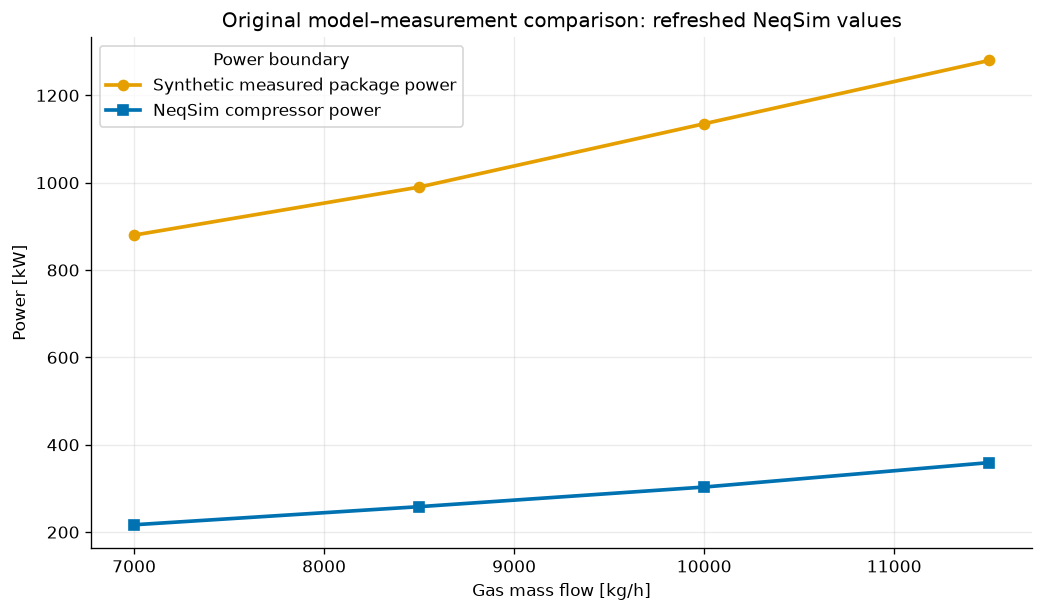

In [11]:
figure, axis = plt.subplots(figsize=(8.8, 5.2))
axis.plot(
    comparison["flow_kg_per_hr"],
    comparison["measured_power_kW"],
    color=COLORS["orange"],
    marker="o",
    linewidth=2.2,
    label="Synthetic measured package power",
)
axis.plot(
    comparison["flow_kg_per_hr"],
    comparison["simulated_power_kW"],
    color=COLORS["blue"],
    marker="s",
    linewidth=2.2,
    label="NeqSim compressor power",
)
axis.set_xlabel("Gas mass flow [kg/h]")
axis.set_ylabel("Power [kW]")
axis.set_title(
    "Original model–measurement comparison: refreshed NeqSim values"
)
axis.legend(title="Power boundary")
plt.tight_layout()
plt.show()


Both series rise with flow and pressure ratio, but their scale and intercept differ. The
next step quantifies the mismatch before applying any calibration.


## 10. Raw model performance

RMSE, mean bias, and mean absolute error are reported in kW. Percentage error uses measured
power as the denominator and is therefore specific to this synthetic package boundary.


In [12]:
def calculate_metrics(observed, predicted):
    observed_values = np.asarray(observed, dtype=float)
    predicted_values = np.asarray(predicted, dtype=float)
    residual_values = observed_values - predicted_values
    return {
        "RMSE [kW]": float(
            np.sqrt(np.mean(np.square(residual_values)))
        ),
        "Bias [kW]": float(np.mean(residual_values)),
        "MAE [kW]": float(np.mean(np.abs(residual_values))),
        "MAPE [%]": float(
            100.0
            * np.mean(
                np.abs(residual_values) / observed_values
            )
        ),
    }


raw_metrics = calculate_metrics(
    comparison["measured_power_kW"],
    comparison["simulated_power_kW"],
)
display(pd.DataFrame([raw_metrics]).round(6))


,RMSE [kW],Bias [kW],MAE [kW],MAPE [%]
0,792.957875,786.896669,786.896669,73.626045


The raw statistics are a baseline, not a failure verdict. They show why model and
measurement boundaries must be reconciled before residuals are interpreted as condition
indicators.


## 11. Transparent package-boundary calibration

The first three preserved rows form a training set. The fourth remains unseen for
validation. An affine correction is used:

$$
\hat{P}_{package} = a\hat{P}_{NeqSim} + b
$$

Scale $a$ is dimensionless and intercept $b$ is in kW. This empirical layer is kept
separate from the thermodynamic compressor efficiency.


In [13]:
training_mask = comparison.index < 3
validation_mask = comparison.index == 3
calibration_scale, calibration_intercept_kw = np.polyfit(
    comparison.loc[training_mask, "simulated_power_kW"],
    comparison.loc[training_mask, "measured_power_kW"],
    deg=1,
)
comparison["calibrated_power_kW"] = (
    calibration_scale * comparison["simulated_power_kW"]
    + calibration_intercept_kw
)
comparison["calibrated_residual_kW"] = (
    comparison["measured_power_kW"]
    - comparison["calibrated_power_kW"]
)
training_metrics = calculate_metrics(
    comparison.loc[training_mask, "measured_power_kW"],
    comparison.loc[training_mask, "calibrated_power_kW"],
)
validation_metrics = calculate_metrics(
    comparison.loc[validation_mask, "measured_power_kW"],
    comparison.loc[validation_mask, "calibrated_power_kW"],
)
calibration_table = pd.DataFrame(
    [
        {
            "Parameter": "Package scale a",
            "Value": calibration_scale,
            "Unit": "-",
        },
        {
            "Parameter": "Package intercept b",
            "Value": calibration_intercept_kw,
            "Unit": "kW",
        },
        {
            "Parameter": "Training RMSE",
            "Value": training_metrics["RMSE [kW]"],
            "Unit": "kW",
        },
        {
            "Parameter": "Validation absolute residual",
            "Value": abs(
                comparison.loc[
                    validation_mask,
                    "calibrated_residual_kW",
                ].iloc[0]
            ),
            "Unit": "kW",
        },
    ]
)
display(calibration_table.round(6))
display(comparison.round(6))


,Parameter,Value,Unit
0,Package scale a,2.955206,-
1,Package intercept b,235.023458,kW
2,Training RMSE,5.829039,kW
3,Validation absolute residual,16.384446,kW


,flow_kg_per_hr,suction_pressure_bara,discharge_pressure_bara,measured_power_kW,simulated_power_kW,discharge_temperature_C,suction_density_kg_per_m3,mass_residual_kg_per_hr,energy_residual_W,residual_kW,calibrated_power_kW,calibrated_residual_kW
0,7000.0,48.0,95.0,880,216.800478,85.536903,41.298242,0.0,0.0,663.199522,875.713519,4.286481
1,8500.0,50.0,98.0,990,258.262144,84.637782,43.227082,0.0,0.0,731.737856,998.241281,-8.241281
2,10000.0,52.0,102.0,1135,303.201117,84.694953,45.172546,0.0,-0.0,831.798883,1131.045200,3.954800
3,11500.0,53.0,106.0,1280,359.149585,86.466593,46.151468,0.0,0.0,920.850415,1296.384446,-16.384446


Validation is deliberately separate. A model that only reproduces its training rows has
not demonstrated predictive usefulness.


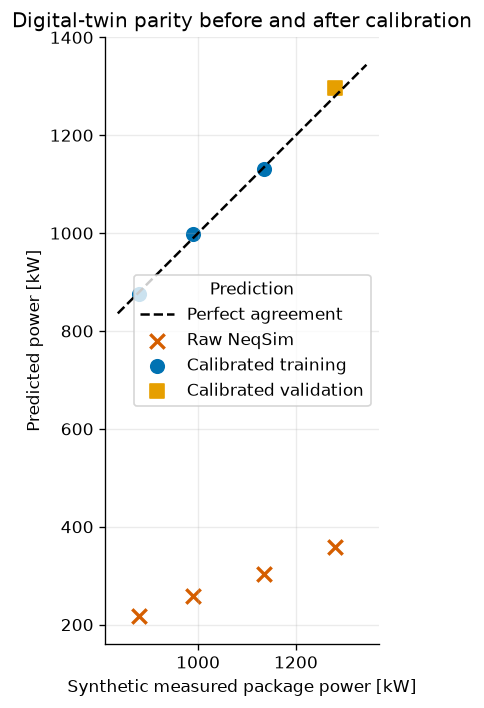

In [14]:
observed_limits = [
    0.95 * comparison["measured_power_kW"].min(),
    1.05 * comparison["measured_power_kW"].max(),
]
figure, axis = plt.subplots(figsize=(6.8, 6.0))
axis.plot(
    observed_limits,
    observed_limits,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Perfect agreement",
)
axis.scatter(
    comparison["measured_power_kW"],
    comparison["simulated_power_kW"],
    color=COLORS["red"],
    marker="x",
    s=75,
    linewidth=2.0,
    label="Raw NeqSim",
)
axis.scatter(
    comparison.loc[training_mask, "measured_power_kW"],
    comparison.loc[training_mask, "calibrated_power_kW"],
    color=COLORS["blue"],
    marker="o",
    s=65,
    label="Calibrated training",
)
axis.scatter(
    comparison.loc[validation_mask, "measured_power_kW"],
    comparison.loc[validation_mask, "calibrated_power_kW"],
    color=COLORS["orange"],
    marker="s",
    s=80,
    label="Calibrated validation",
)
axis.set_xlabel("Synthetic measured package power [kW]")
axis.set_ylabel("Predicted power [kW]")
axis.set_title("Digital-twin parity before and after calibration")
axis.legend(title="Prediction")
axis.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


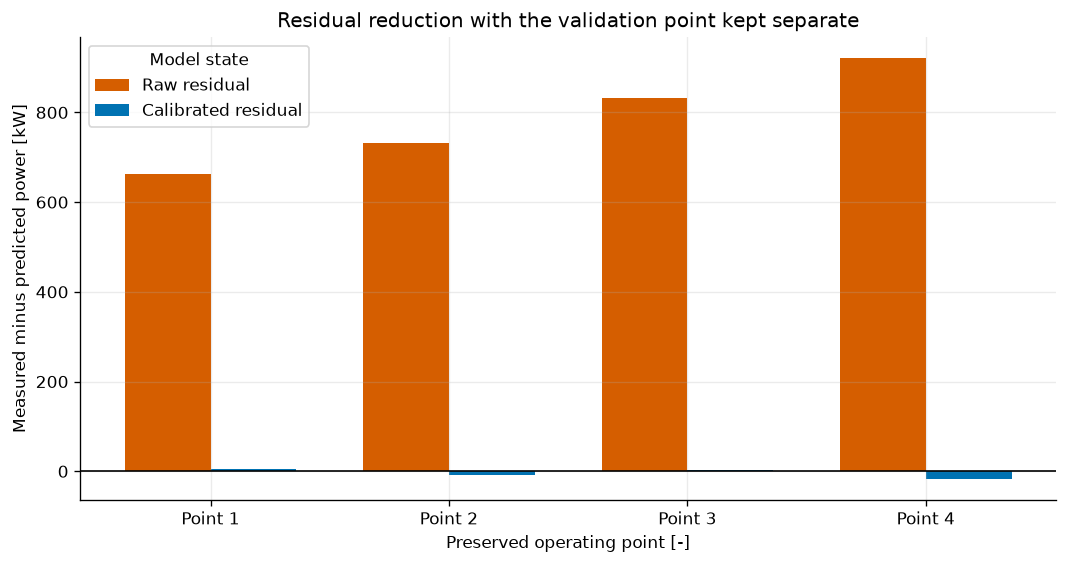

In [15]:
figure, axis = plt.subplots(figsize=(9.0, 4.8))
x_positions = np.arange(len(comparison))
width = 0.36
axis.bar(
    x_positions - width / 2.0,
    comparison["residual_kW"],
    width,
    color=COLORS["red"],
    label="Raw residual",
)
axis.bar(
    x_positions + width / 2.0,
    comparison["calibrated_residual_kW"],
    width,
    color=COLORS["blue"],
    label="Calibrated residual",
)
axis.axhline(0.0, color="black", linewidth=1.0)
axis.set_xticks(x_positions)
axis.set_xticklabels(
    [f"Point {index + 1}" for index in x_positions]
)
axis.set_xlabel("Preserved operating point [-]")
axis.set_ylabel("Measured minus predicted power [kW]")
axis.set_title(
    "Residual reduction with the validation point kept separate"
)
axis.legend(title="Model state")
plt.tight_layout()
plt.show()


The parity and residual figures show the raw physics result, the training fit, and the
unseen validation point separately. The remaining validation error becomes part of the
monitoring uncertainty rather than being silently tuned away.


## 12. Efficiency sensitivity

Package calibration and compressor efficiency are different concepts. This sensitivity
varies the physical efficiency at a fixed operating point to show the expected inverse
relationship between efficiency and shaft power.


,Isentropic efficiency [-],Power [kW],Discharge temperature [°C]
0,0.68,347.789516,90.605398
1,0.70,337.852673,89.286731
2,0.72,328.467877,88.042053
3,0.74,319.590366,86.865359
4,0.76,311.180094,85.751268
5,0.78,303.201117,84.694953
6,0.80,295.621089,83.692066
7,0.82,288.410819,82.738681
8,0.84,281.543894,81.831248


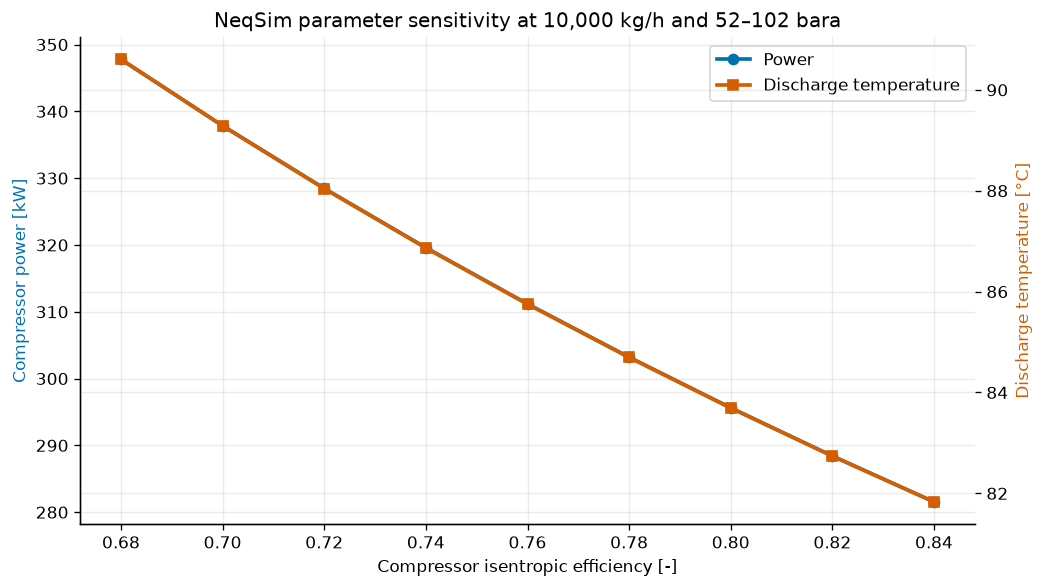

In [16]:
efficiency_values = np.linspace(0.68, 0.84, 9)
efficiency_rows = []

for efficiency_value in efficiency_values:
    sensitivity_case = simulate_compressor_case(
        flow_kg_h=10000.0,
        suction_pressure_bara=52.0,
        discharge_pressure_bara=102.0,
        isentropic_efficiency=float(efficiency_value),
    )
    efficiency_rows.append(
        {
            "Isentropic efficiency [-]": efficiency_value,
            "Power [kW]": sensitivity_case["result"][
                "simulated_power_kW"
            ],
            "Discharge temperature [°C]": sensitivity_case["result"][
                "discharge_temperature_C"
            ],
        }
    )

efficiency_sensitivity = pd.DataFrame(efficiency_rows)
display(efficiency_sensitivity.round(6))

figure, power_axis = plt.subplots(figsize=(8.8, 5.0))
temperature_axis = power_axis.twinx()
power_axis.plot(
    efficiency_sensitivity["Isentropic efficiency [-]"],
    efficiency_sensitivity["Power [kW]"],
    color=COLORS["blue"],
    marker="o",
    linewidth=2.2,
    label="Power",
)
temperature_axis.plot(
    efficiency_sensitivity["Isentropic efficiency [-]"],
    efficiency_sensitivity["Discharge temperature [°C]"],
    color=COLORS["red"],
    marker="s",
    linewidth=2.2,
    label="Discharge temperature",
)
power_axis.set_xlabel("Compressor isentropic efficiency [-]")
power_axis.set_ylabel("Compressor power [kW]", color=COLORS["blue"])
temperature_axis.set_ylabel(
    "Discharge temperature [°C]",
    color=COLORS["red"],
)
power_axis.set_title(
    "NeqSim parameter sensitivity at 10,000 kg/h and 52–102 bara"
)
lines = power_axis.lines + temperature_axis.lines
power_axis.legend(
    lines,
    [line.get_label() for line in lines],
    loc="upper right",
)
plt.tight_layout()
plt.show()


Higher efficiency reduces both power and discharge temperature. The monotonic response is
an important limiting-case check before any efficiency parameter is estimated.


## 13. Native NeqSim batch parameter estimation

NeqSim 3.16.0 includes `BatchParameterEstimator`, a bounded Levenberg–Marquardt framework
for historical calibration. This controlled example generates four synthetic discharge
temperatures with a known efficiency of 0.76, then estimates that efficiency from an
initial guess of 0.65. Flow is fixed because the current path accessor supports
single-argument setters; `setFlowRate(value, unit)` is outside this example's path contract.


In [17]:
estimator_pressures_bara = [90.0, 100.0, 110.0, 120.0]
known_efficiency = 0.76
synthetic_temperature_rows = []

for outlet_pressure_bara in estimator_pressures_bara:
    known_case = simulate_compressor_case(
        flow_kg_h=9000.0,
        suction_pressure_bara=50.0,
        discharge_pressure_bara=outlet_pressure_bara,
        isentropic_efficiency=known_efficiency,
    )
    synthetic_temperature_rows.append(
        {
            "Outlet pressure [bara]": outlet_pressure_bara,
            "Synthetic measured temperature [K]": (
                known_case["objects"][
                    "compressor"
                ].getOutletStream().getTemperature("K")
            ),
        }
    )

synthetic_temperature_data = pd.DataFrame(
    synthetic_temperature_rows
)
display(synthetic_temperature_data.round(8))


,Outlet pressure [bara],Synthetic measured temperature [K]
0,90.0,350.931008
1,100.0,360.742990
2,110.0,369.701352
3,120.0,377.945220


In [18]:
estimator_fluid = make_gas(
    temperature_c=25.0,
    pressure_bara=50.0,
    flow_kg_h=9000.0,
)
estimator_feed = Stream("Estimator feed", estimator_fluid)
estimator_compressor = Compressor(
    "Estimator compressor",
    estimator_feed,
)
estimator_compressor.setOutletPressure(100.0, "bara")
estimator_compressor.setIsentropicEfficiency(0.65)
estimator_process = ProcessSystem()
estimator_process.add(estimator_feed)
estimator_process.add(estimator_compressor)
estimator_process.run()

BatchParameterEstimator = (
    jneqsim.process.calibration.BatchParameterEstimator
)
estimator = BatchParameterEstimator(estimator_process)
estimator.addTunableParameter(
    "Estimator compressor.isentropicEfficiency",
    "-",
    0.50,
    0.90,
    0.65,
)
estimator.addMeasuredVariable(
    "Estimator compressor.outletStream.temperature",
    "K",
    0.20,
)
HashMap = JClass("java.util.HashMap")

for _, data_row in synthetic_temperature_data.iterrows():
    conditions = HashMap()
    conditions.put(
        "Estimator compressor.outletPressure",
        JDouble(data_row["Outlet pressure [bara]"]),
    )
    measured_values = HashMap()
    measured_values.put(
        "Estimator compressor.outletStream.temperature",
        JDouble(
            data_row["Synthetic measured temperature [K]"]
        ),
    )
    estimator.addDataPoint(conditions, measured_values)

estimator.setMaxIterations(30)
estimator_log = io.StringIO()

with contextlib.redirect_stdout(estimator_log):
    batch_result = estimator.solve()

estimated_efficiency = batch_result.getEstimate(0)
efficiency_uncertainty = batch_result.getUncertainty(0)
batch_summary = pd.DataFrame(
    [
        {
            "Known efficiency [-]": known_efficiency,
            "Initial guess [-]": 0.65,
            "Estimated efficiency [-]": estimated_efficiency,
            "Uncertainty [-]": efficiency_uncertainty,
            "RMSE [K]": batch_result.getRMSE(),
            "R² [-]": batch_result.getRSquared(),
            "Converged": batch_result.isConverged(),
        }
    ]
)
display(batch_summary.round(10))


,Known efficiency [-],Initial guess [-],Estimated efficiency [-],Uncertainty [-],RMSE [K],R² [-],Converged
0,0.76,0.65,0.76,0.001651,0.000078,1.0,True


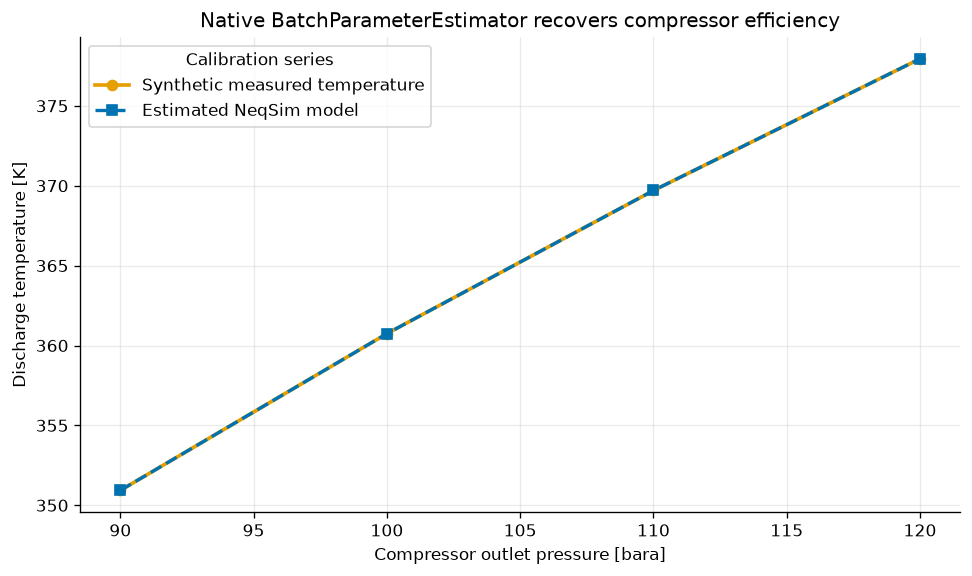

In [19]:
estimated_temperature_rows = []

for _, data_row in synthetic_temperature_data.iterrows():
    estimated_case = simulate_compressor_case(
        flow_kg_h=9000.0,
        suction_pressure_bara=50.0,
        discharge_pressure_bara=float(
            data_row["Outlet pressure [bara]"]
        ),
        isentropic_efficiency=estimated_efficiency,
    )
    estimated_temperature_rows.append(
        estimated_case["objects"][
            "compressor"
        ].getOutletStream().getTemperature("K")
    )

synthetic_temperature_data["Estimated-model temperature [K]"] = (
    estimated_temperature_rows
)
figure, axis = plt.subplots(figsize=(8.2, 4.9))
axis.plot(
    synthetic_temperature_data["Outlet pressure [bara]"],
    synthetic_temperature_data[
        "Synthetic measured temperature [K]"
    ],
    color=COLORS["orange"],
    marker="o",
    linewidth=2.2,
    label="Synthetic measured temperature",
)
axis.plot(
    synthetic_temperature_data["Outlet pressure [bara]"],
    synthetic_temperature_data[
        "Estimated-model temperature [K]"
    ],
    color=COLORS["blue"],
    marker="s",
    linestyle="--",
    linewidth=2.0,
    label="Estimated NeqSim model",
)
axis.set_xlabel("Compressor outlet pressure [bara]")
axis.set_ylabel("Discharge temperature [K]")
axis.set_title(
    "Native BatchParameterEstimator recovers compressor efficiency"
)
axis.legend(title="Calibration series")
plt.tight_layout()
plt.show()


The native estimator recovers the known efficiency and reports an uncertainty and fit
statistics. Production use requires independent data, credible sensor uncertainty,
parameter identifiability analysis, bounds, and validation outside the calibration window.


## 14. Final application: 24-hour model-in-the-loop monitoring

A deterministic synthetic historian is created from changing flow and pressure conditions.
Every hour is simulated with fresh NeqSim objects. Package-level power uses the preserved
calibration, deterministic sensor noise, and a gradual positive drift beginning at hour 16.
The drift is an injected teaching signal, not a benchmark or diagnosis.


In [20]:
hour_values = np.arange(24)
monitoring_basis = pd.DataFrame(
    {
        "Hour [-]": hour_values,
        "Flow [kg/h]": (
            9000.0
            + 1400.0 * np.sin(2.0 * np.pi * hour_values / 24.0)
            + 35.0 * hour_values
        ),
        "Suction pressure [bara]": (
            50.0
            + 1.8
            * np.sin(
                2.0 * np.pi * (hour_values + 3.0) / 24.0
            )
        ),
        "Discharge pressure [bara]": (
            101.0
            + 3.5
            * np.cos(
                2.0 * np.pi * (hour_values + 1.0) / 24.0
            )
        ),
    }
)
display(monitoring_basis.head().round(6))


,Hour [-],Flow [kg/h],Suction pressure [bara],Discharge pressure [bara]
0,0,9000.000000,51.272792,104.380740
1,1,9397.346663,51.558846,104.031089
2,2,9770.000000,51.738666,103.474874
3,3,10094.949494,51.800000,102.750000
4,4,10352.435565,51.738666,101.905867


In [21]:
monitoring_rows = []

for _, basis_row in monitoring_basis.iterrows():
    monitoring_case = simulate_compressor_case(
        flow_kg_h=float(basis_row["Flow [kg/h]"]),
        suction_pressure_bara=float(
            basis_row["Suction pressure [bara]"]
        ),
        discharge_pressure_bara=float(
            basis_row["Discharge pressure [bara]"]
        ),
        isentropic_efficiency=model_basis[
            "isentropic_efficiency"
        ],
    )
    monitoring_rows.append(
        {
            **basis_row.to_dict(),
            **monitoring_case["result"],
        }
    )

monitoring_results = pd.DataFrame(monitoring_rows)
noise_pattern_kw = np.asarray(
    [
        -5.0,
        3.0,
        1.0,
        -4.0,
        5.0,
        -2.0,
        2.0,
        -1.0,
        4.0,
        -3.0,
        0.0,
        2.0,
        -4.0,
        3.0,
        -1.0,
        2.0,
        1.0,
        -2.0,
        3.0,
        -1.0,
        2.0,
        -2.0,
        1.0,
        0.0,
    ]
)
drift_kw = np.where(
    monitoring_results["Hour [-]"] >= 16,
    6.0 * (monitoring_results["Hour [-]"] - 15.0),
    0.0,
)
monitoring_results["Calibrated baseline power [kW]"] = (
    calibration_scale * monitoring_results["simulated_power_kW"]
    + calibration_intercept_kw
)
monitoring_results["Synthetic measured power [kW]"] = (
    monitoring_results["Calibrated baseline power [kW]"]
    + noise_pattern_kw
    + drift_kw
)
monitoring_results["Monitoring residual [kW]"] = (
    monitoring_results["Synthetic measured power [kW]"]
    - monitoring_results["Calibrated baseline power [kW]"]
)
monitoring_results["Rolling residual [kW]"] = monitoring_results[
    "Monitoring residual [kW]"
].rolling(window=3, min_periods=3).mean()
residual_threshold_kw = max(
    20.0,
    3.0
    * comparison.loc[
        training_mask,
        "calibrated_residual_kW",
    ].std(ddof=1),
)
monitoring_results["Alert"] = (
    monitoring_results["Rolling residual [kW]"].abs()
    > residual_threshold_kw
)
display(monitoring_results.round(6))


,Hour [-],Flow [kg/h],Suction pressure [bara],Discharge pressure [bara],flow_kg_per_hr,suction_pressure_bara,discharge_pressure_bara,simulated_power_kW,discharge_temperature_C,suction_density_kg_per_m3,mass_residual_kg_per_hr,energy_residual_W,Calibrated baseline power [kW],Synthetic measured power [kW],Monitoring residual [kW],Rolling residual [kW],Alert
0,0.0,9000.000000,51.272792,104.380740,9000.000000,51.272792,104.380740,289.823271,88.117990,44.463253,0.0,0.0,1091.510909,1086.510909,-5.0,NaN,False
1,1.0,9397.346663,51.558846,104.031089,9397.346663,51.558846,104.031089,298.298262,87.294150,44.741999,0.0,0.0,1116.556255,1119.556255,3.0,NaN,False
2,2.0,9770.000000,51.738666,103.474874,9770.000000,51.738666,103.474874,305.739974,86.479023,44.917400,0.0,-0.0,1138.548045,1139.548045,1.0,-0.333333,False
3,3.0,10094.949494,51.800000,102.750000,10094.949494,51.800000,102.750000,311.763860,85.723438,44.977256,0.0,0.0,1156.349868,1152.349868,-4.0,0.000000,False
4,4.0,10352.435565,51.738666,101.905867,10352.435565,51.738666,101.905867,316.128911,85.075207,44.917400,0.0,0.0,1169.249493,1174.249493,5.0,0.666667,False
5,5.0,10527.296157,51.558846,101.000000,10527.296157,51.558846,101.000000,318.731850,84.576819,44.741999,0.0,0.0,1176.941715,1174.941715,-2.0,-0.333333,False
6,6.0,10610.000000,51.272792,100.094133,10610.000000,51.272792,100.094133,319.585910,84.263019,44.463253,0.0,0.0,1179.465637,1181.465637,2.0,1.666667,False
7,7.0,10597.296157,50.900000,99.250000,10597.296157,50.900000,99.250000,318.791897,84.158295,44.100492,0.0,0.0,1177.119166,1176.119166,-1.0,-0.333333,False
8,8.0,10492.435565,50.465874,98.525126,10492.435565,50.465874,98.525126,316.510237,84.274465,43.678773,0.0,0.0,1170.376390,1174.376390,4.0,1.666667,False
9,9.0,10304.949494,50.000000,97.968911,10304.949494,50.000000,97.968911,312.941676,84.608650,43.227082,0.0,0.0,1159.830557,1156.830557,-3.0,0.000000,False


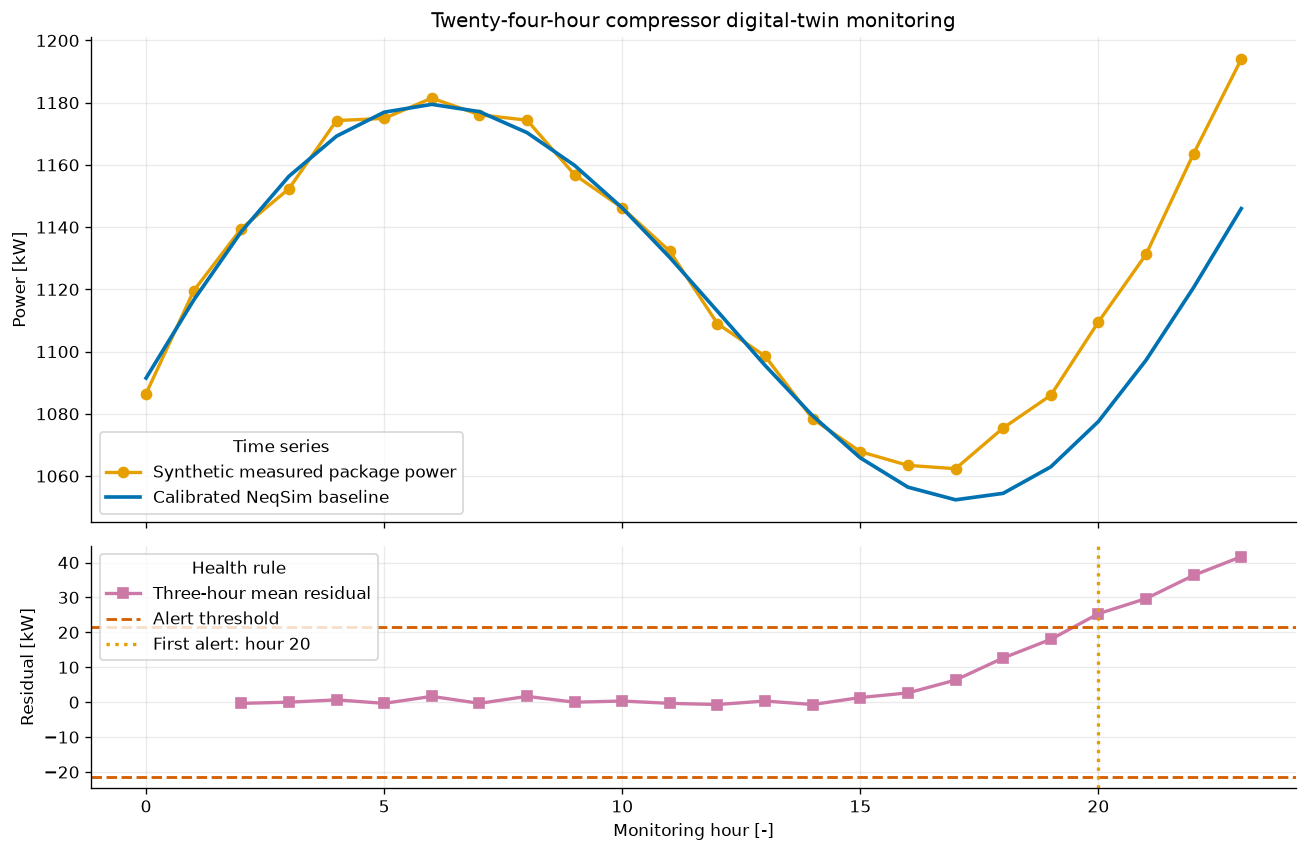

In [22]:
alert_rows = monitoring_results[monitoring_results["Alert"]]
first_alert_hour = (
    int(alert_rows["Hour [-]"].iloc[0])
    if not alert_rows.empty
    else None
)
figure, axes = plt.subplots(
    2,
    1,
    figsize=(11.0, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]},
)
axes[0].plot(
    monitoring_results["Hour [-]"],
    monitoring_results["Synthetic measured power [kW]"],
    color=COLORS["orange"],
    marker="o",
    linewidth=2.0,
    label="Synthetic measured package power",
)
axes[0].plot(
    monitoring_results["Hour [-]"],
    monitoring_results["Calibrated baseline power [kW]"],
    color=COLORS["blue"],
    linewidth=2.2,
    label="Calibrated NeqSim baseline",
)
axes[0].set_ylabel("Power [kW]")
axes[0].set_title(
    "Twenty-four-hour compressor digital-twin monitoring"
)
axes[0].legend(title="Time series")

axes[1].plot(
    monitoring_results["Hour [-]"],
    monitoring_results["Rolling residual [kW]"],
    color=COLORS["purple"],
    marker="s",
    linewidth=2.0,
    label="Three-hour mean residual",
)
axes[1].axhline(
    residual_threshold_kw,
    color=COLORS["red"],
    linestyle="--",
    linewidth=1.7,
    label="Alert threshold",
)
axes[1].axhline(
    -residual_threshold_kw,
    color=COLORS["red"],
    linestyle="--",
    linewidth=1.7,
)

if first_alert_hour is not None:
    axes[1].axvline(
        first_alert_hour,
        color=COLORS["orange"],
        linestyle=":",
        linewidth=2.0,
        label=f"First alert: hour {first_alert_hour}",
    )

axes[1].set_xlabel("Monitoring hour [-]")
axes[1].set_ylabel("Residual [kW]")
axes[1].legend(title="Health rule", loc="upper left")
plt.tight_layout()
plt.show()


The calibrated baseline follows changing process conditions because every point is
recomputed by NeqSim. The rule reacts only after the injected residual persists long enough
to move the three-hour mean above its threshold.


## 15. Machine-readable twin snapshot

A production twin needs a stable result contract. The snapshot records model version,
calibration, current conditions, residual, threshold, alert state, and limitations.


In [23]:
latest_monitoring_row = monitoring_results.iloc[-1]
twin_snapshot = {
    "schema": "neqsim.digital_twin.compressor_snapshot.v1",
    "model": {
        "neqsim_version": neqsim_version,
        "thermodynamic_model": "SRK",
        "mixing_rule": "classic",
        "isentropic_efficiency": model_basis[
            "isentropic_efficiency"
        ],
    },
    "calibration": {
        "package_scale": calibration_scale,
        "package_intercept_kW": calibration_intercept_kw,
        "training_points": 3,
        "validation_points": 1,
    },
    "latest": {
        "hour": int(latest_monitoring_row["Hour [-]"]),
        "flow_kg_per_h": latest_monitoring_row["Flow [kg/h]"],
        "suction_pressure_bara": latest_monitoring_row[
            "Suction pressure [bara]"
        ],
        "discharge_pressure_bara": latest_monitoring_row[
            "Discharge pressure [bara]"
        ],
        "measured_power_kW": latest_monitoring_row[
            "Synthetic measured power [kW]"
        ],
        "baseline_power_kW": latest_monitoring_row[
            "Calibrated baseline power [kW]"
        ],
        "rolling_residual_kW": latest_monitoring_row[
            "Rolling residual [kW]"
        ],
        "alert": bool(latest_monitoring_row["Alert"]),
    },
    "monitoring": {
        "threshold_kW": residual_threshold_kw,
        "first_alert_hour": first_alert_hour,
    },
    "limitations": [
        "synthetic measurements",
        "no compressor map or anti-surge model",
        "affine package-boundary calibration",
        "demonstration threshold, not an operating alarm",
    ],
}
print(json.dumps(twin_snapshot, indent=2))


{
  "schema": "neqsim.digital_twin.compressor_snapshot.v1",
  "model": {
    "neqsim_version": "3.16.0",
    "thermodynamic_model": "SRK",
    "mixing_rule": "classic",
    "isentropic_efficiency": 0.78
  },
  "calibration": {
    "package_scale": 2.9552059389990637,
    "package_intercept_kW": 235.0234584919761,
    "training_points": 3,
    "validation_points": 1
  },
  "latest": {
    "hour": 23,
    "flow_kg_per_h": 9442.65333685647,
    "suction_pressure_bara": 50.9,
    "discharge_pressure_bara": 104.5,
    "measured_power_kW": 1193.964332699255,
    "baseline_power_kW": 1145.964332699255,
    "rolling_residual_kW": 41.666666666666664,
    "alert": true
  },
  "monitoring": {
    "threshold_kW": 21.41725583013834,
    "first_alert_hour": 20
  },
  "limitations": [
    "synthetic measurements",
    "no compressor map or anti-surge model",
    "affine package-boundary calibration",
    "demonstration threshold, not an operating alarm"
  ]
}


## 16. Conservation and numerical checks

A digital twin is not accepted merely because its plots look plausible. The compressor
boundary is audited using mass flow and the gas enthalpy-rate rise. The component molar
balance compares the first feed and discharge streams.


In [24]:
first_case_objects = model_cases[0]["objects"]
first_feed = first_case_objects["feed"]
first_discharge = first_case_objects[
    "compressor"
].getOutletStream()
component_names = list(original_composition)


def component_molar_rates(stream_object):
    stream_fluid = stream_object.getFluid()
    total_molar_rate = stream_object.getFlowRate("mole/sec")
    return np.asarray(
        [
            total_molar_rate
            * stream_fluid.getComponent(component_name).getz()
            for component_name in component_names
        ]
    )


component_residuals = (
    component_molar_rates(first_feed)
    - component_molar_rates(first_discharge)
)
audit_table = pd.DataFrame(
    [
        {
            "Check": "Maximum model-row mass residual",
            "Residual": comparison[
                "mass_residual_kg_per_hr"
            ].abs().max(),
            "Unit": "kg/h",
        },
        {
            "Check": "Maximum component residual",
            "Residual": np.max(np.abs(component_residuals)),
            "Unit": "mol/s",
        },
        {
            "Check": "Maximum compressor energy residual",
            "Residual": comparison[
                "energy_residual_W"
            ].abs().max(),
            "Unit": "W",
        },
    ]
)
display(audit_table)


,Check,Residual,Unit
0,Maximum model-row mass residual,0.000000e+00,kg/h
1,Maximum component residual,0.000000e+00,mol/s
2,Maximum compressor energy residual,5.820766e-11,W


The residuals close at floating-point precision relative to the modeled flows and powers.
This validates bookkeeping and units, not the synthetic package calibration.


## 17. Final engineering acceptance gate

These assertions cover preservation, data quality, finite results, physical trends,
calibration separation, native estimator recovery, monitoring behavior, and balances.


In [25]:
engineering_checks = {
    "original measurements preserved": measurements.to_dict(
        orient="list"
    )
    == {
        "flow_kg_per_hr": [7000, 8500, 10000, 11500],
        "suction_pressure_bara": [48, 50, 52, 53],
        "discharge_pressure_bara": [95, 98, 102, 106],
        "measured_power_kW": [880, 990, 1135, 1280],
    },
    "composition closes": math.isclose(
        sum(original_composition.values()),
        1.0,
        abs_tol=1.0e-12,
    ),
    "four original model cases": len(comparison) == 4,
    "measurement quality passed": measurement_quality[
        "Passed"
    ].all(),
    "model power finite": np.isfinite(
        comparison["simulated_power_kW"]
    ).all(),
    "model power positive": comparison[
        "simulated_power_kW"
    ].gt(0.0).all(),
    "model power increases": np.all(
        np.diff(comparison["simulated_power_kW"]) > 0.0
    ),
    "discharge hotter than suction": comparison[
        "discharge_temperature_C"
    ].gt(model_basis["temperature_c"]).all(),
    "mass balance": comparison[
        "mass_residual_kg_per_hr"
    ].abs().max()
    < 1.0e-8,
    "component balance": np.max(
        np.abs(component_residuals)
    )
    < 1.0e-8,
    "compressor energy balance": comparison[
        "energy_residual_W"
    ].abs().max()
    < 1.0e-6,
    "calibration scale positive": calibration_scale > 0.0,
    "training RMSE below 10 kW": (
        training_metrics["RMSE [kW]"] < 10.0
    ),
    "validation residual below 20 kW": (
        validation_metrics["MAE [kW]"] < 20.0
    ),
    "efficiency sensitivity monotonic": np.all(
        np.diff(efficiency_sensitivity["Power [kW]"]) < 0.0
    ),
    "native estimator converged": batch_result.isConverged(),
    "native efficiency recovered": math.isclose(
        estimated_efficiency,
        known_efficiency,
        abs_tol=1.0e-4,
    ),
    "native uncertainty finite": math.isfinite(
        efficiency_uncertainty
    )
    and efficiency_uncertainty > 0.0,
    "native calibration RMSE small": (
        batch_result.getRMSE() < 1.0e-3
    ),
    "monitoring has 24 rows": len(monitoring_results) == 24,
    "monitoring finite": np.isfinite(
        monitoring_results[
            [
                "simulated_power_kW",
                "Calibrated baseline power [kW]",
                "Synthetic measured power [kW]",
            ]
        ].to_numpy()
    ).all(),
    "no alert before drift": not monitoring_results.loc[
        monitoring_results["Hour [-]"] < 16,
        "Alert",
    ].any(),
    "sustained drift detected": first_alert_hour is not None
    and first_alert_hour >= 16,
    "latest snapshot alerts": twin_snapshot["latest"]["alert"],
}

failed_checks = [
    check_name
    for check_name, passed in engineering_checks.items()
    if not passed
]

assert not failed_checks, failed_checks
print(f"All {len(engineering_checks)} engineering checks passed.")


All 24 engineering checks passed.


## 18. Troubleshooting

- **NeqSim import fails:** rerun setup in a fresh Colab CPU runtime.
- **Java does not start:** avoid manually injecting a JAR or mixing local checkouts.
- **Residuals are huge:** reconcile tag units, timestamps, measurement and model boundaries,
  auxiliaries, and efficiency definitions before tuning.
- **Calibration is unstable:** reduce correlated parameters, tighten physical bounds, add
  diverse steady-state data, and inspect sensitivity.
- **Path accessor fails:** confirm the exact equipment name and use supported
  single-argument getter/setter paths.
- **Alerts chatter:** validate sensor uncertainty, persistence, deadband, and operating
  regimes before choosing a production threshold.
- **Results depend on row order:** create fresh NeqSim objects for each operating point.


## 19. Summary

The notebook preserves the original gas, measurements, row-by-row compressor simulations,
and comparison figure. It repairs obsolete compatibility imports, implicit efficiency,
weak units and labels, mutable workflow risks, missing balances, and absent validation.

It now teaches real NeqSim functionality: fluid flashes, connected process objects,
equipment results, native batch parameter estimation, uncertainty, scenario sensitivity,
model–measurement calibration, 24-hour monitoring, drift detection, and a structured twin
snapshot.


## 20. Further exercises

1. Replace the affine package correction with reconciled motor, gearbox, and auxiliary tags.
2. Add a vendor compressor map, speed, anti-surge margin, and mechanical loss.
3. Use `EnKFParameterEstimator` for sequential efficiency tracking with uncertainty.
4. Add steady-state detection and timestamp alignment before model evaluation.
5. Compare SRK and Peng–Robinson against a versioned composition and laboratory data.
6. Introduce redundant measurements and use NeqSim data reconciliation before calibration.
7. Connect a governed historian reader only after adding authentication, schema validation,
   rate limiting, audit logging, and safe failure behavior.


## References

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim process simulation](https://equinor.github.io/neqsim/process/)
- [NeqSim process calibration framework](https://equinor.github.io/neqsim/process/calibration/)
- [Data reconciliation and parameter estimation](https://equinor.github.io/neqsim/calibration/data_reconciliation_parameter_estimation)
- [NeqSim Python package on PyPI](https://pypi.org/project/neqsim/)
- [NeqSim source repository](https://github.com/equinor/neqsim)

Accessed 23 July 2026. All measurements in this notebook are synthetic and reproducible.
